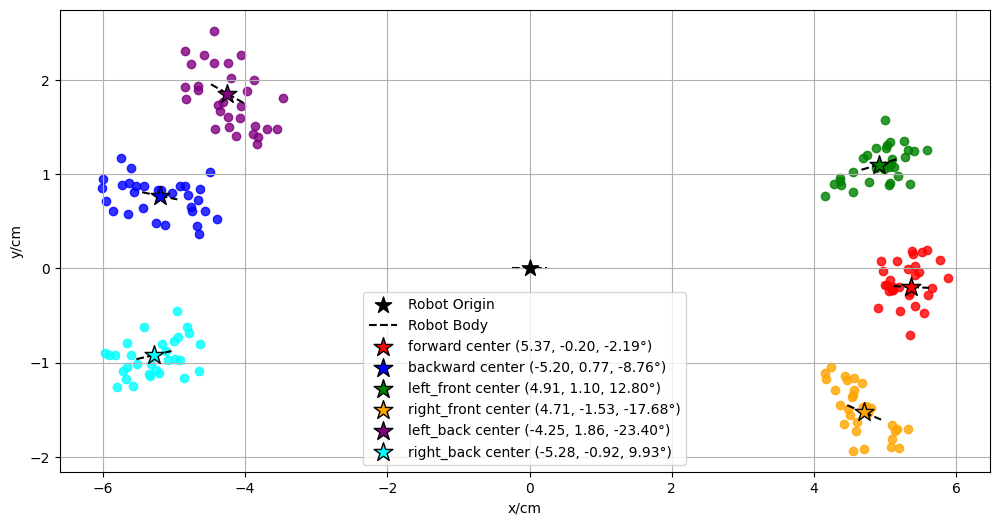

In [8]:
import json
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

# Assume this notebook is in repo/software/
HERE = Path.cwd()
REPO = HERE if (HERE / "raw_gaits_data").exists() else HERE.parent
DATA_DIR = REPO / "raw_gaits_data"
FIG_DIR  = REPO / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

def load_gait_data(gait_name):
    """Load gait data from raw_gaits_data/{gait}_data.json."""
    filename = DATA_DIR / f"{gait_name}_data.json"
    data = []
    try:
        with open(filename, "r") as file:
            for line in file:
                data.append(json.loads(line))
    except FileNotFoundError:
        print(f"File {filename} not found.")
    return data

def normalize_angle(angle):
    """Normalize an angle to the range [-180, 180]."""
    return ((angle + 180) % 360) - 180

def rotate_and_translate(delta_distance, delta_theta, gait_name):
    """
    Convert Δdistance and Δtheta to Δx, Δy in the global frame,
    adjusted for gait-specific motion directions.
    """
    # Update heading (in radians)
    new_theta = np.radians(delta_theta)

    # Compute global Δx and Δy
    delta_x = delta_distance * np.cos(new_theta)
    delta_y = delta_distance * np.sin(new_theta)

    if gait_name == "forward":
        return delta_x, delta_y
    elif gait_name == "backward":
        return -delta_x, delta_y
    elif gait_name == "left_front":
        return delta_x, -delta_y
    elif gait_name == "right_front":
        return delta_x, -delta_y
    elif gait_name == "left_back":
        return -delta_x, delta_y
    elif gait_name == "right_back":
        return -delta_x, delta_y
    else:
        raise ValueError(f"Unknown gait name: {gait_name}")

def remove_outliers(data):
    """Remove outliers using the IQR method."""
    Q1 = np.percentile(data, 25, axis=0)
    Q3 = np.percentile(data, 75, axis=0)
    IQR = Q3 - Q1

    # Define bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Keep only points within the bounds
    return data[
        (data[:, 0] >= lower_bound[0]) & (data[:, 0] <= upper_bound[0]) &
        (data[:, 1] >= lower_bound[1]) & (data[:, 1] <= upper_bound[1])
    ]

def filter_closest_points(data, center, n):
    """Filter the n closest points to the cluster center."""
    distances = np.sqrt((data[:, 0] - center[0])**2 + (data[:, 1] - center[1])**2)
    closest_indices = np.argsort(distances)[:n]
    return data[closest_indices]

def plot_comparison(clean_data_dict, n_closest=None, robot_width=0.5):
    """Plot comparison of x, y positions for all gaits."""
    colors = ["red", "blue", "green", "orange", "purple", "cyan"]
    gaits = list(clean_data_dict.keys())
    legend_handles = []  # To customize the legend

    plt.figure(figsize=(12, 6))

    # Draw the original robot position
    origin_handle = plt.scatter(0, 0, color="black", marker="*", s=150, label="Robot Origin", zorder=3)
    robot_body_handle, = plt.plot(
        [-robot_width / 2, robot_width / 2],
        [0, 0],
        color="black",
        linestyle="--",
        zorder=1,  # Lower z-order for the robot body line
        label="Robot Body"
    )
    legend_handles.append(origin_handle)
    legend_handles.append(robot_body_handle)

    for i, gait in enumerate(gaits):
        clean_data = clean_data_dict[gait]
        delta_x2 = np.array([entry["delta_x2"] for entry in clean_data])
        delta_y2 = np.array([entry["delta_y2"] for entry in clean_data])
        delta_theta = np.array([entry["delta_theta"] for entry in clean_data])

        data = np.column_stack((delta_x2, delta_y2))

        # Remove outliers
        filtered_data = remove_outliers(data)

        # Calculate cluster center without outliers
        center_x = np.mean(filtered_data[:, 0])
        center_y = np.mean(filtered_data[:, 1])
        center_theta = np.mean(delta_theta)  # Average orientation

        if gait == "forward":
            center_theta = center_theta
        else:
            center_theta = -center_theta  # Invert angle for other gaits

        center = np.array([center_x, center_y])

        # Filter closest n points if specified
        if n_closest is not None:
            filtered_data = filter_closest_points(filtered_data, center, n_closest)
            delta_x2, delta_y2 = filtered_data[:, 0], filtered_data[:, 1]
        else:
            delta_x2, delta_y2 = filtered_data[:, 0], filtered_data[:, 1]

        # Scatter plot for x, y positions as dots
        data_handle = plt.scatter(
            delta_x2, delta_y2, color=colors[i], label=f"{gait}", alpha=0.8, marker="o", zorder=1
        )

        # Represent center with a star (*) with black edge
        center_handle = plt.scatter(
            center[0], center[1], color=colors[i], marker="*", s=200, edgecolor="black", zorder=3
        )

        # Draw dashed lines for robot body style at center in black
        line_length = 0.5  # Total length of the dashed line segments
        front_x = center_x + (line_length / 2) * np.cos(np.radians(center_theta))
        front_y = center_y + (line_length / 2) * np.sin(np.radians(center_theta))
        back_x = center_x - (line_length / 2) * np.cos(np.radians(center_theta))
        back_y = center_y - (line_length / 2) * np.sin(np.radians(center_theta))
        plt.plot(
            [back_x, center_x],
            [back_y, center_y],
            color="black",
            linestyle="--",
            linewidth=1.5,
            zorder=2  # Lower z-order for the line
        )
        plt.plot(
            [center_x, front_x],
            [center_y, front_y],
            color="black",
            linestyle="--",
            linewidth=1.5,
            zorder=2  # Lower z-order for the line
        )

        # Add the center label to the legend
        legend_handles.append(center_handle)
        legend_handles[-1].set_label(
            f"{gait} center ({center_x:.2f}, {center_y:.2f}, {center_theta:.2f}°)"
        )

    plt.xlabel("x/cm")
    plt.ylabel("y/cm")
    plt.legend(handles=legend_handles, loc="best")
    plt.grid(True)
    plt.savefig(FIG_DIR / "plot_comparison.png", dpi=300, bbox_inches="tight")

    # plt.show()




def plot_distance_vs_theta(clean_data_dict, n_closest=None):
    """Plot comparison of Δdistance vs Δtheta for all gaits."""
    colors = ["red", "blue", "green", "orange", "purple", "cyan"]
    gaits = list(clean_data_dict.keys())

    plt.figure(figsize=(12, 6))

    for i, gait in enumerate(gaits):
        clean_data = clean_data_dict[gait]
        delta_distance = np.array([entry["delta_distance"] for entry in clean_data])
        delta_theta = np.array([entry["delta_theta"] for entry in clean_data])

        data = np.column_stack((delta_distance, delta_theta))

        # Remove outliers
        filtered_data = remove_outliers(data)

        # Calculate cluster center without outliers
        center_x = np.mean(filtered_data[:, 0])
        center_y = np.mean(filtered_data[:, 1])
        center = np.array([center_x, center_y])

        # Filter closest n points if specified
        if n_closest is not None:
            filtered_data = filter_closest_points(filtered_data, center, n_closest)
            delta_distance, delta_theta = filtered_data[:, 0], filtered_data[:, 1]
        else:
            delta_distance, delta_theta = filtered_data[:, 0], filtered_data[:, 1]

        # Scatter plot for Δdistance vs Δtheta as dots
        plt.scatter(delta_distance, delta_theta, color=colors[i], label=f"{gait}", alpha=0.8, marker="o")

        # Represent center with a large 'x'
        plt.scatter(center[0], center[1], color=colors[i], marker="x", s=200, edgecolor="black")

    plt.xlabel("Δdistance")
    plt.ylabel("Δθ")
    # plt.xlim(0, 10) 
    plt.legend()
    plt.grid(True)
    plt.show()


if __name__ == "__main__":
    gaits = ["forward", "backward", "left_front", "right_front", "left_back", "right_back"]
    clean_data_dict = {}

    for gait in gaits:
        raw_data = load_gait_data(gait)

        delta_data = []
        for entry in raw_data:
            # Raw data deltas
            delta_x1 = entry["goal_x"] - entry["start_x"]
            delta_y1 = entry["goal_y"] - entry["start_y"]
            delta_distance = np.sqrt(delta_x1**2 + delta_y1**2)
            delta_theta = normalize_angle(entry["goal_theta"] - entry["start_theta"])

            # Calculated deltas
            delta_x2, delta_y2 = rotate_and_translate(
                delta_distance, delta_theta, gait
            )

            delta_data.append({
                "delta_x1": delta_x1,
                "delta_y1": delta_y1,
                "delta_x2": delta_x2,
                "delta_y2": delta_y2,
                "delta_distance": delta_distance,
                "delta_theta": delta_theta,
            })

        clean_data_dict[gait] = delta_data

    # Number of closest points to use (None = use all points)
    n_closest_points = 30

    # Plot Δx_2 vs Δy_2
    plot_comparison(clean_data_dict, n_closest=n_closest_points)

